<a href="https://colab.research.google.com/github/latebutcan/VisionTransformer-Comparison/blob/main/122140236_RayhanFadelIrwanto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# --- BAGIAN 1: INSTALASI & IMPORT ---
# Install library timm (PyTorch Image Models) dan grad-cam untuk visualisasi
!pip install timm scikit-learn matplotlib seaborn grad-cam

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os
import zipfile

# Setup Device (GPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan Hardware: {device}")
if device.type == 'cuda':
    print(f"GPU Info: {torch.cuda.get_device_name(0)}")


Menggunakan Hardware: cpu


In [3]:
# --- BAGIAN 2: REORGANISASI DATASET ---
nama_file_zip = 'IF25-4041-dataset.zip'
zip_path = f'/content/{nama_file_zip}'
extract_path = '/content/dataset'

# 1. Ekstrak
if not os.path.exists(extract_path):
    print(f"Mengekstrak {nama_file_zip}...")
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ Ekstraksi selesai.")
    else:
        print(f"❌ ERROR: File {nama_file_zip} belum diupload!")
else:
    print("Folder dataset sudah ada.")

# 2. Rapikan Folder berdasarkan CSV (PENTING!)
csv_path = os.path.join(extract_path, 'train.csv')
train_img_dir = os.path.join(extract_path, 'train')

if os.path.exists(csv_path) and os.path.exists(train_img_dir):
    # Cek apakah masih berantakan (gambar jpg ada di root folder train?)
    files = [f for f in os.listdir(train_img_dir) if f.lower().endswith('.jpg')]

    if len(files) > 0:
        print(f"Sedang merapikan {len(files)} gambar ke folder kelas...")
        df = pd.read_csv(csv_path)
        # Asumsi: Kolom 1 = Nama File, Kolom 2 = Label
        col_file, col_label = df.columns[0], df.columns[1]

        count = 0
        for _, row in df.iterrows():
            fname = str(row[col_file])
            label = str(row[col_label])

            if not fname.lower().endswith('.jpg'): fname += '.jpg'

            src = os.path.join(train_img_dir, fname)
            dst_dir = os.path.join(train_img_dir, label)
            dst = os.path.join(dst_dir, fname)

            if os.path.exists(src):
                os.makedirs(dst_dir, exist_ok=True)
                shutil.move(src, dst)
                count += 1
        print(f"✅ Berhasil memindahkan {count} gambar.")
    else:
        print("✅ Struktur dataset sudah rapi (gambar sudah dalam folder kelas).")
else:
    print("⚠️ Info: CSV tidak ditemukan atau struktur folder sudah berubah.")

Folder dataset sudah ada.
✅ Struktur dataset sudah rapi (gambar sudah dalam folder kelas).


In [4]:
# --- BAGIAN 3: DATALOADER (HEMAT RAM) ---
target_dir = os.path.join(extract_path, 'train')

# Transformasi Gambar (ViT butuh 224x224) [cite: 193]
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
}

# Load ImageFolder
try:
    full_dataset = datasets.ImageFolder(target_dir, transform=data_transforms['train'])
    class_names = full_dataset.classes
    print(f"Kelas Ditemukan: {class_names}")

    # Split 80/20
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    val_dataset.dataset.transform = data_transforms['val']

    # --- KONFIGURASI ANTI-CRASH ---
    BATCH_SIZE = 16  # Kecilkan ini agar RAM muat
    NUM_WORKERS = 0  # Matikan multiprocessing

    dataloaders = {
        'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS),
        'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    }
    dataset_sizes = {'train': train_size, 'val': val_size}
    print(f"✅ Data Siap! Train: {train_size}, Val: {val_size}")

except Exception as e:
    print(f"❌ ERROR Load Data: {e}")
    print("Pastikan Bagian 2 sudah sukses dijalankan.")

Kelas Ditemukan: ['bakso', 'gado_gado', 'nasi_goreng', 'rendang', 'soto_ayam']
✅ Data Siap! Train: 886, Val: 222


In [5]:
# --- BAGIAN 4: DEFINISI FUNGSI ---
def train_model(model, criterion, optimizer, num_epochs=3):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            print(f'   {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    return model, history

def evaluate_model(model, name):
    model.eval()
    y_true, y_pred = [], []

    # Ukur Waktu [cite: 46]
    start = time.time()
    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    end = time.time()

    avg_time = ((end - start) / dataset_sizes['val']) * 1000
    acc = accuracy_score(y_true, y_pred)

    print(f"\n--- Hasil {name} ---")
    print(f"Akurasi: {acc:.4f}")
    print(f"Waktu Inferensi: {avg_time:.2f} ms/img")

    # Matriks & Report [cite: 35-42]
    print(classification_report(y_true, y_pred, target_names=class_names))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    return avg_time, acc


 MULAI MODEL: vit_tiny_patch16_224 
Downloading/Loading vit_tiny_patch16_224...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Total Parameters: 5,525,381
Epoch 1/3
   train Loss: 0.4293 Acc: 0.8510


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


   val Loss: 0.2716 Acc: 0.9369
Epoch 2/3
   train Loss: 0.0203 Acc: 0.9955
   val Loss: 0.1293 Acc: 0.9640
Epoch 3/3
   train Loss: 0.0021 Acc: 1.0000
   val Loss: 0.1171 Acc: 0.9685

--- Hasil vit_tiny_patch16_224 ---
Akurasi: 0.9685
Waktu Inferensi: 88.52 ms/img
              precision    recall  f1-score   support

       bakso       1.00      0.98      0.99        45
   gado_gado       0.95      0.98      0.96        41
 nasi_goreng       0.98      0.95      0.96        42
     rendang       0.96      0.96      0.96        47
   soto_ayam       0.96      0.98      0.97        47

    accuracy                           0.97       222
   macro avg       0.97      0.97      0.97       222
weighted avg       0.97      0.97      0.97       222



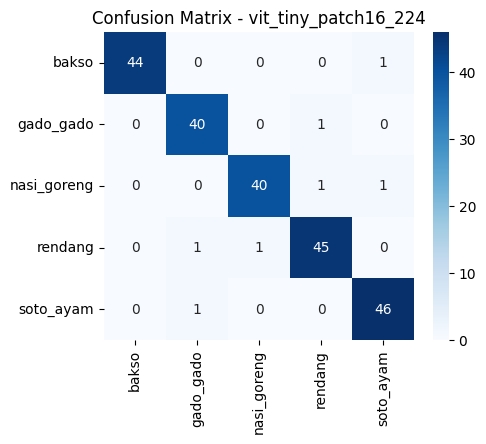

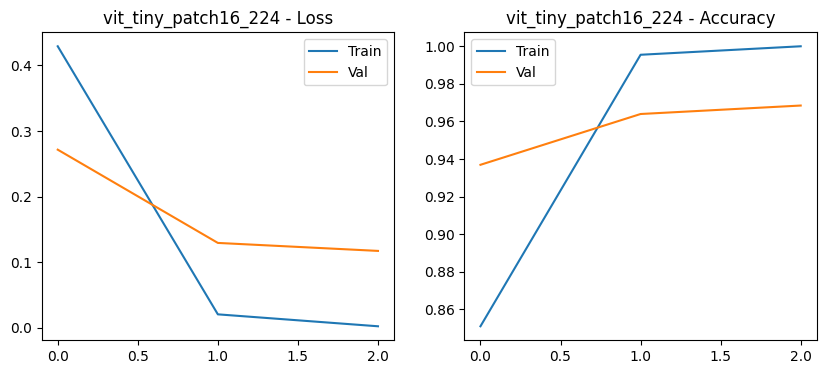


 MULAI MODEL: swin_tiny_patch4_window7_224 
Downloading/Loading swin_tiny_patch4_window7_224...


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Total Parameters: 27,523,199
Epoch 1/3
   train Loss: 0.4797 Acc: 0.8386


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


   val Loss: 0.1317 Acc: 0.9459
Epoch 2/3
   train Loss: 0.0750 Acc: 0.9808
   val Loss: 0.1262 Acc: 0.9595
Epoch 3/3
   train Loss: 0.1092 Acc: 0.9628
   val Loss: 0.0744 Acc: 0.9730

--- Hasil swin_tiny_patch4_window7_224 ---
Akurasi: 0.9730
Waktu Inferensi: 274.65 ms/img
              precision    recall  f1-score   support

       bakso       0.98      0.98      0.98        45
   gado_gado       1.00      0.98      0.99        41
 nasi_goreng       0.95      0.95      0.95        42
     rendang       0.98      0.96      0.97        47
   soto_ayam       0.96      1.00      0.98        47

    accuracy                           0.97       222
   macro avg       0.97      0.97      0.97       222
weighted avg       0.97      0.97      0.97       222



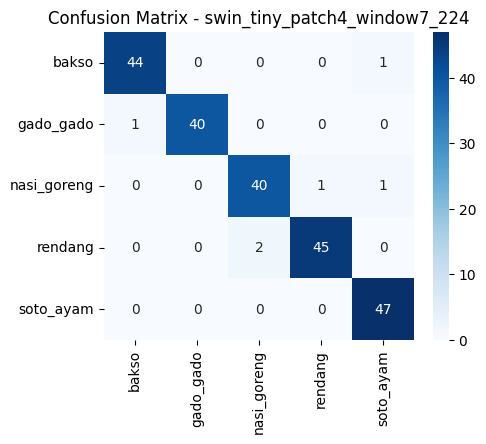

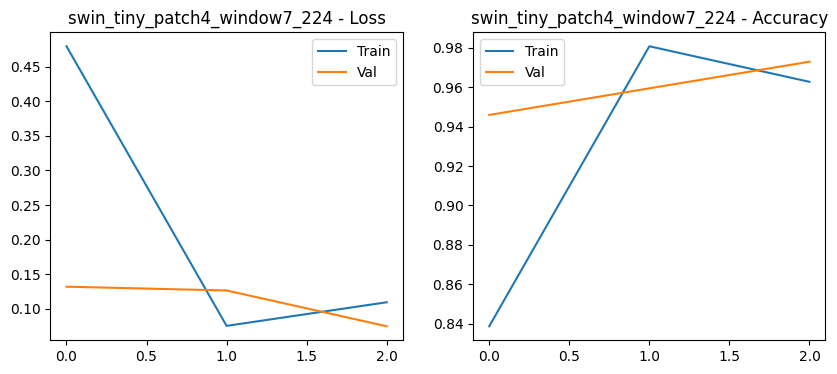


 MULAI MODEL: deit_tiny_patch16_224 
Downloading/Loading deit_tiny_patch16_224...


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Total Parameters: 5,525,381
Epoch 1/3
   train Loss: 0.6382 Acc: 0.7743


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


   val Loss: 0.1595 Acc: 0.9505
Epoch 2/3
   train Loss: 0.0654 Acc: 0.9853
   val Loss: 0.1681 Acc: 0.9550
Epoch 3/3
   train Loss: 0.0290 Acc: 0.9921
   val Loss: 0.1243 Acc: 0.9550

--- Hasil deit_tiny_patch16_224 ---
Akurasi: 0.9550
Waktu Inferensi: 87.70 ms/img
              precision    recall  f1-score   support

       bakso       0.98      0.93      0.95        45
   gado_gado       0.89      0.98      0.93        41
 nasi_goreng       1.00      0.95      0.98        42
     rendang       0.96      0.96      0.96        47
   soto_ayam       0.96      0.96      0.96        47

    accuracy                           0.95       222
   macro avg       0.96      0.96      0.96       222
weighted avg       0.96      0.95      0.96       222



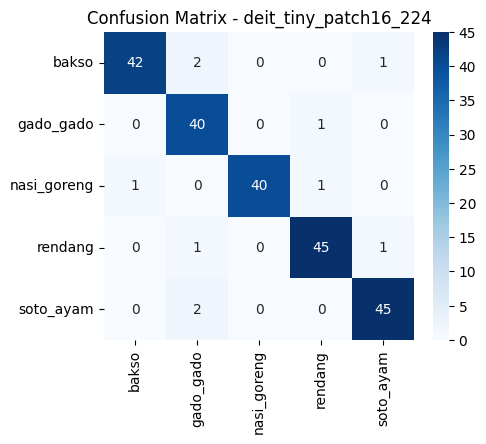

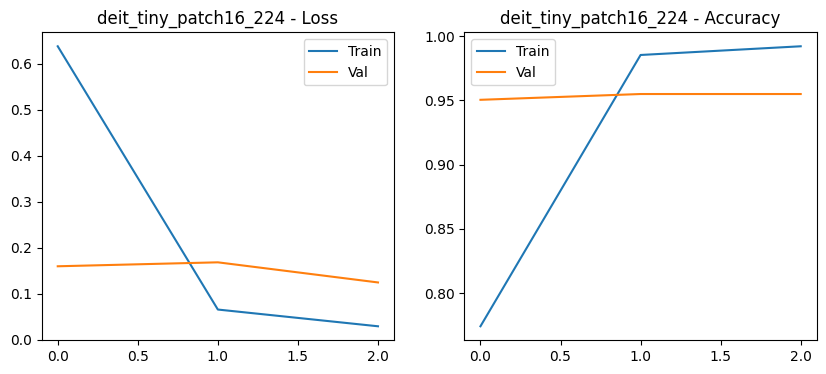

In [8]:
# --- BAGIAN 5: TRAINING 3 MODEL (BONUS +8%) ---
import gc  # <--- PERBAIKAN: Import Garbage Collector
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import matplotlib.pyplot as plt

# Daftar model versi Tiny (Hemat RAM)
models_list = [
    'vit_tiny_patch16_224',          # ViT Tiny
    'swin_tiny_patch4_window7_224',  # Swin Tiny
    'deit_tiny_patch16_224'          # DeiT Tiny
]

results = {}

for m_name in models_list:
    print(f"\n{'='*30}\n MULAI MODEL: {m_name} \n{'='*30}")

    # 1. Bersihkan RAM dulu (PENTING!)
    torch.cuda.empty_cache()
    gc.collect()

    # 2. Load Model Pre-trained
    try:
        print(f"Downloading/Loading {m_name}...")
        model = timm.create_model(m_name, pretrained=True, num_classes=len(class_names))
        model = model.to(device)
    except Exception as e:
        print(f"❌ Gagal load {m_name}: {e}")
        continue

    # [cite_start]3. Hitung Parameter [cite: 30-31]
    params = sum(p.numel() for p in model.parameters())
    print(f"Total Parameters: {params:,}")

    # 4. Training
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    # Panggil fungsi train_model yang sudah didefinisikan di Bagian 4
    # Pastikan Bagian 4 sudah dijalankan sebelumnya!
    trained_model, history = train_model(model, criterion, optimizer, num_epochs=3)

    # 5. Evaluasi
    inf_time, final_acc = evaluate_model(trained_model, m_name)

    # 6. Simpan Hasil
    results[m_name] = {
        'params': params,
        'acc': final_acc,
        'time': inf_time,
        'model': trained_model,
        'hist': history
    }

    # [cite_start]7. Plot Kurva Loss/Acc [cite: 44-45]
    plt.figure(figsize=(10, 4))
    plt.subplot(1,2,1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Val')
    plt.title(f'{m_name} - Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['val_acc'], label='Val')
    plt.title(f'{m_name} - Accuracy')
    plt.legend()
    plt.show()


=== 🌟 GALERI VISUALISASI ATTENTION MAP (BONUS) ===

🔍 Membuat Visualisasi untuk: vit_tiny_patch16_224...


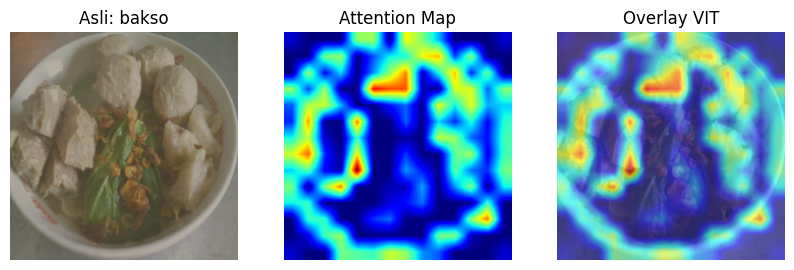


🔍 Membuat Visualisasi untuk: swin_tiny_patch4_window7_224...


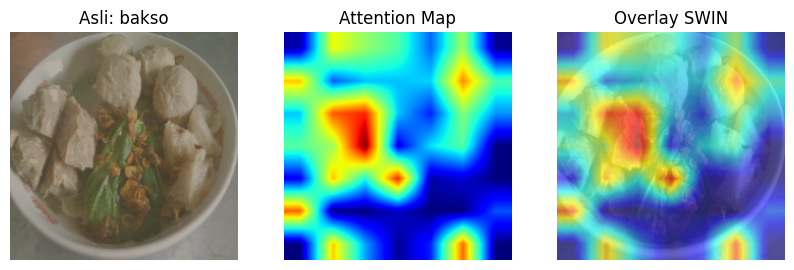


🔍 Membuat Visualisasi untuk: deit_tiny_patch16_224...


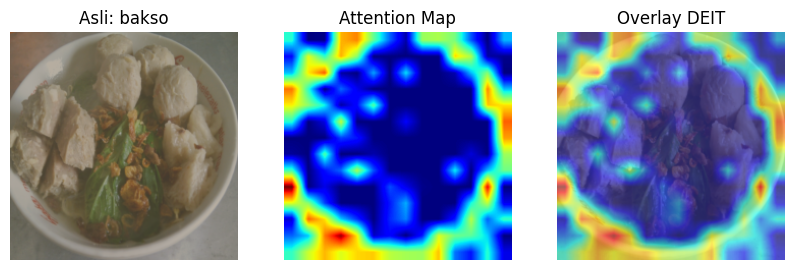

In [11]:
# --- BAGIAN 6: VISUALISASI LENGKAP (ViT, Swin, DeiT) ---
import numpy as np
import matplotlib.pyplot as plt
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# --- 1. FUNGSI TRANSFORMASI KHUSUS (Agar tidak Error Shape) ---

def reshape_transform_vit_deit(tensor):
    """
    Untuk ViT dan DeiT yang berbasis Patch.
    Menangani 1 token CLS (ViT) atau 2 token (DeiT Distilled).
    """
    # Hitung jumlah patch sisi (misal 224/16 = 14)
    # Total patch = 14x14 = 196
    height = 14
    width = 14

    # Cek jumlah token untuk menentukan berapa yang harus diskip
    # tensor shape: (Batch, Seq_Len, Feature)
    seq_len = tensor.shape[1]

    if seq_len == 197: # 196 patch + 1 CLS token (ViT Standard)
        tensor = tensor[:, 1:, :]
    elif seq_len == 198: # 196 patch + 1 CLS + 1 Distill (DeiT Distilled)
        tensor = tensor[:, 2:, :]

    # Susun ulang jadi 2D Image (B, H, W, C) -> (B, C, H, W)
    result = tensor.reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

def reshape_transform_swin(tensor):
    """
    Untuk Swin Transformer.
    Output Swin biasanya sudah (Batch, H, W, Channel) atau (Batch, L, C)
    """
    # Jika shape sudah 4D (B, H, W, C), tinggal ubah ke (B, C, H, W)
    if len(tensor.shape) == 4:
        return tensor.permute(0, 3, 1, 2)

    # Jika shape 3D (Batch, Length, Channel), harus di-reshape
    # Untuk Swin Tiny input 224, output stage terakhir biasanya 7x7
    else:
        height = 7
        width = 7
        result = tensor.reshape(tensor.size(0), height, width, tensor.size(2))
        result = result.transpose(2, 3).transpose(1, 2)
        return result

# --- 2. FUNGSI VISUALISASI UTAMA ---

def visualize_model_attention(model_name, results_dict, dataset, class_names):
    if model_name not in results_dict:
        print(f"⚠️ Model {model_name} tidak ditemukan di hasil training.")
        return

    print(f"\n🔍 Membuat Visualisasi untuk: {model_name}...")

    try:
        model = results_dict[model_name]['model']
        target_layers = []
        transform_func = None

        # A. KONFIGURASI ViT & DeiT
        if 'vit' in model_name or 'deit' in model_name:
            # Target: Layer Normalization terakhir (sebelum classifier)
            target_layers = [model.blocks[-1].norm1]
            transform_func = reshape_transform_vit_deit

        # B. KONFIGURASI SWIN
        elif 'swin' in model_name:
            # Target: Layer Norm terakhir di Stage terakhir
            target_layers = [model.layers[-1].blocks[-1].norm1]
            transform_func = reshape_transform_swin

        # C. EKSEKUSI GRAD-CAM
        cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=transform_func)

        # Ambil 1 gambar sample
        img_tensor, label_idx = dataset[0]
        input_tensor = img_tensor.unsqueeze(0).to(device)

        # Generate Heatmap
        grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(label_idx)])[0, :]

        # Denormalisasi Gambar Asli
        rgb_img = img_tensor.cpu().permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        rgb_img = std * rgb_img + mean
        rgb_img = np.clip(rgb_img, 0, 1)

        # Overlay
        viz = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        # Plotting
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(rgb_img)
        plt.title(f"Asli: {class_names[label_idx]}")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(grayscale_cam, cmap='jet')
        plt.title("Attention Map")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(viz)
        plt.title(f"Overlay {model_name.split('_')[0].upper()}")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"❌ Gagal memvisualisasikan {model_name}: {e}")

# --- 3. LOOP UNTUK SEMUA MODEL ---

print("\n=== 🌟 GALERI VISUALISASI ATTENTION MAP (BONUS) ===")

# Loop semua model yang ada di results
model_list = ['vit_tiny_patch16_224', 'swin_tiny_patch4_window7_224', 'deit_tiny_patch16_224']

for m in model_list:
    visualize_model_attention(m, results, val_dataset, class_names)